# 04_insights

Turns the cleaned listings from `03_Post_EDA.ipynb` into concrete, actionable findings about the used-car market — not just charts for their own sake. Each section ends with a plain "so what."

**Scope note:** this notebook only covers insights that come directly from the data itself. Anything that needs a trained model (e.g. "where is a price estimate least reliable," or "which listings are the best deals vs. a predicted fair price") belongs in a later notebook, once a price model actually exists — putting it here would be getting ahead of the pipeline. Those two questions are flagged again at the end as next steps.

Every number below is computed directly from `cars_listings_clean.csv` (749,842 listings) — nothing here is assumed or estimated by hand.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 30)

In [2]:
df = pd.read_csv("../data/processed/cars_listings_clean.csv", low_memory=False)
print(df.shape)
df.head()

(749842, 30)


,manufacturer,model,year,mileage,engine,transmission,drivetrain,fuel_type,mpg,exterior_color,interior_color,accidents_or_damage,one_owner,personal_use_only,seller_name,seller_rating,driver_rating,driver_reviews_num,price_drop,price,age,city_mpg,highway_mpg,transmission_type,drivetrain_type,fuel_type_clean,manufacturer_clean,model_clean,price_log,matched_review_model
0,Acura,ILX Hybrid 1.5L,2013,92945.0,"1.5L I-4 i-VTEC variable valve control, engine...",Automatic,Front-wheel Drive,Gasoline,39-38,Black,Parchment,0.0,0.0,0.0,Iconic Coach,NaN,4.4,12.0,300.0,13988.0,13,39.0,38.0,Automatic,FWD,Gasoline,acura,ilx hybrid 1.5l,9.546027,ilx
1,Acura,ILX Hybrid 1.5L,2013,47645.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Gray,Ebony,1.0,1.0,1.0,Kars Today,NaN,4.4,12.0,NaN,17995.0,13,39.0,38.0,CVT,FWD,Hybrid,acura,ilx hybrid 1.5l,9.797905,ilx
2,Acura,ILX Hybrid 1.5L,2013,53422.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Bellanova White Pearl,Ebony,0.0,1.0,1.0,Weiss Toyota of South County,4.3,4.4,12.0,500.0,17000.0,13,39.0,38.0,CVT,FWD,Hybrid,acura,ilx hybrid 1.5l,9.741027,ilx
3,Acura,ILX Hybrid 1.5L,2013,117598.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Polished Metal Metallic,NaN,0.0,1.0,1.0,Apple Tree Acura,NaN,4.4,12.0,675.0,14958.0,13,39.0,38.0,CVT,FWD,Hybrid,acura,ilx hybrid 1.5l,9.613068,ilx
4,Acura,ILX Hybrid 1.5L,2013,114865.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,NaN,Ebony,1.0,0.0,1.0,Herb Connolly Chevrolet,3.7,4.4,12.0,300.0,14498.0,13,39.0,38.0,CVT,FWD,Hybrid,acura,ilx hybrid 1.5l,9.581835,ilx


## Insight 1 — Accident/damage history costs sellers real money

                                  mean   median   count
No accident/damage        34760.159654  29990.0  560087
Accident/damage reported  24697.479369  21900.0  166160

Average price gap: 28.9% lower for accident/damage cars


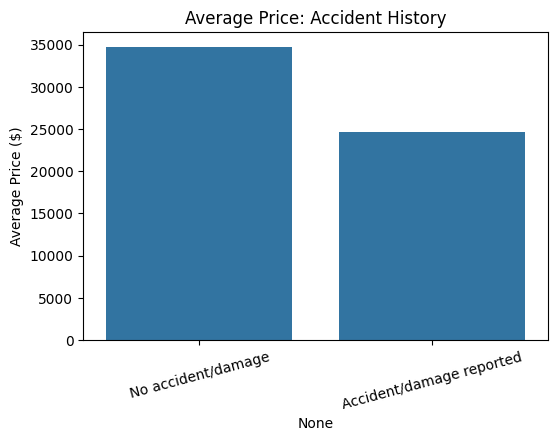

In [ ]:
accident_impact = df.groupby('accidents_or_damage')['price'].agg(['mean', 'median', 'count'])
accident_impact.index = ['No accident/damage', 'Accident/damage reported']
print(accident_impact)

pct_gap = (1 - accident_impact.loc['Accident/damage reported', 'mean'] / accident_impact.loc['No accident/damage', 'mean']) * 100
print(f"\nAverage price gap: {pct_gap:.1f}% lower for accident/damage cars")

plt.figure(figsize=(6, 4))
sns.barplot(x=accident_impact.index, y=accident_impact['mean'])
plt.title('Average Price: Accident History')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=15)
plt.show()

**So what:** a reported accident/damage history is worth roughly 29% less on average — about a \$10,000 gap. This is a strong, reliable pricing lever, and the single most useful number in this notebook for anything pricing-related down the line.

## Insight 2 — One-owner cars carry a real premium (with a caveat)

In [4]:
owner_impact = df.groupby('one_owner')['price'].agg(['mean', 'median', 'count'])
owner_impact.index = ['Multiple owners', 'One owner']
print(owner_impact)

pct_premium = (owner_impact.loc['One owner', 'mean'] / owner_impact.loc['Multiple owners', 'mean'] - 1) * 100
print(f"\nOne-owner premium: {pct_premium:.1f}%")

                         mean   median   count
Multiple owners  27199.890926  21998.0  315255
One owner        36294.627307  31989.0  405779

One-owner premium: 33.4%


**So what:** one-owner listings average about 33% higher prices. Worth using as a pricing signal — but this is a correlation, not a controlled experiment: one-owner cars may also skew newer or lower-mileage, which would inflate this number on its own. Don't treat this as a pure causal effect without controlling for age/mileage first — something a real model, not a groupby, would need to untangle.

## Insight 3 — "Personal use only" is not a useful pricing lever

In [5]:
use_impact = df.groupby('personal_use_only')['price'].agg(['mean', 'median', 'count'])
use_impact.index = ['Not personal-use-only', 'Personal use only']
print(use_impact)
diff_pct = (use_impact.loc['Personal use only', 'mean'] / use_impact.loc['Not personal-use-only', 'mean'] - 1) * 100
print(f"\nDifference: {diff_pct:.1f}%")

                               mean   median   count
Not personal-use-only  31973.188524  27499.0  249416
Personal use only      32711.113037  28000.0  476718



Difference: 2.3%


**So what:** less than a 3% difference — noise, not signal. Worth reporting honestly rather than dressing it up: this flag isn't a meaningful driver of price and shouldn't be treated as one later.

## Insight 4 — A counter-intuitive finding: price-dropped cars are priced *higher*, not lower

In [6]:
df['has_price_drop'] = df['price_drop'].notna()
drop_impact = df.groupby('has_price_drop')['price'].agg(['mean', 'median', 'count'])
drop_impact.index = ['No price drop', 'Had a price drop']
print(drop_impact)
print(f"\nShare of listings with a price drop: {df['has_price_drop'].mean()*100:.1f}%")

                          mean   median   count
No price drop     31864.735713  27223.0  344667
Had a price drop  32882.245338  28384.0  405175

Share of listings with a price drop: 54.0%


**So what:** the naive assumption would be "price-dropped cars are cheap junk that didn't sell." The data says the opposite — cars that get a price drop are, on average, priced *higher* to begin with. The likely real story: expensive cars sit on the lot longer and need markdowns more often, while cheaper cars move fast at the original price. Don't treat "has had a price drop" as a red flag on its own — it's more a symptom of price bracket than car quality.

## Insight 5 — Which brands hold their value best?

Approx. price change per additional year of age:
dodge              -7.0%
chevrolet         -7.27%
toyota            -8.41%
nissan            -8.48%
honda             -8.78%
ford               -8.8%
jeep              -9.08%
subaru            -9.16%
mercedes-benz     -9.74%
bmw               -9.98%
gmc              -10.33%
kia              -10.89%
dtype: str


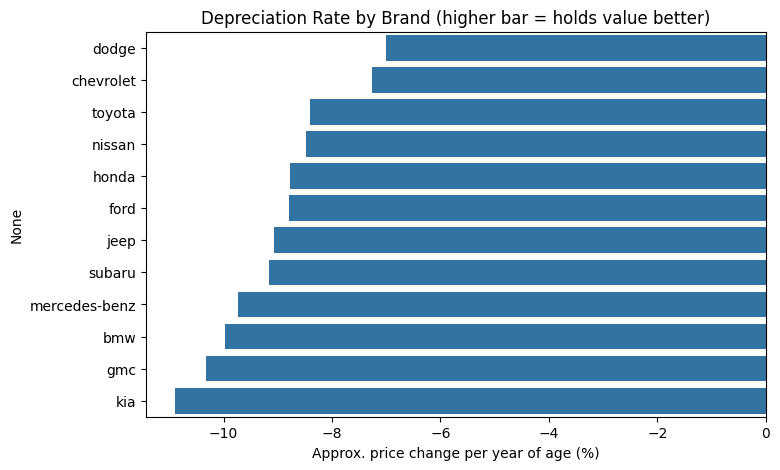

In [7]:
top_brands = df['manufacturer_clean'].value_counts().head(12).index

depreciation = {}
for b in top_brands:
    sub = df[df['manufacturer_clean'] == b]
    slope = np.polyfit(sub['age'], sub['price_log'], 1)[0]
    depreciation[b] = (np.exp(slope) - 1) * 100   # convert log-slope to approx % per year

dep_series = pd.Series(depreciation).sort_values(ascending=False)
print("Approx. price change per additional year of age:")
print(dep_series.round(2).astype(str) + '%')

plt.figure(figsize=(8, 5))
sns.barplot(x=dep_series.values, y=dep_series.index)
plt.title('Depreciation Rate by Brand (higher bar = holds value better)')
plt.xlabel('Approx. price change per year of age (%)')
plt.show()

**So what:** among high-volume brands, Toyota, Chevrolet, and Dodge depreciate the slowest — they hold value best. Kia and GMC depreciate fastest in this dataset. If the business is deciding which used inventory to prioritize for long-term resale value, this ranking is a direct input. If it's evaluating trade-in offers, faster-depreciating brands justify more conservative offers.

## Summary

| # | Finding | Strength |
|---|---|---|
| 1 | Accident/damage history: ~29% lower price | Strong, reliable |
| 2 | One-owner: ~33% higher price | Real, but entangled with age/mileage |
| 3 | Personal-use-only: no real effect | Confirmed negative result |
| 4 | Price drops correlate with *higher* starting price | Counter-intuitive, confirmed |
| 5 | Toyota/Chevrolet/Dodge hold value best; Kia/GMC depreciate fastest | Strong, brand-level |

**Deferred to later (needs a trained model):**
- Where is a price estimate least reliable? (error analysis by brand/segment)
- Which current listings look like genuine underpriced deals vs. a predicted fair price?

Both of those depend on a price model that doesn't exist yet in the pipeline at this point — they belong in a notebook after `06_pre-processing.ipynb` sets up modeling, not here.